<h2 style="text-align: center;">НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ 
<br/>МОСКОВСКИЙ ЭНЕРГЕТИЧЕСКИЙ ИНСТИТУТ</h2>
</br>
<h3 style="text-align: center;">Кафедра Паровых и Газовых Турбин</h3>

</br>
</br>
</br>
</br>
</br>

<h1 style="text-align: center;">Курсовая работа по курсу:</h1>
<h1 style="text-align: center;">«Паровые и газовые турбины»</h1>

</br>
</br>
</br>
</br>
</br>

<h5 style="text-align: right;">Студент: Шалыгин Никита Александрович </h5>
<h5 style="text-align: right;">Группа: ФПэ-01-22</h5>

</br>
</br>
</br>
</br>
</br>
</br>
</br>



<h5 style="text-align: center;">Москва 2025</h5>

# Вариант №11

### $\space$ Дано:
* $P_0 = 26 \space МПа $ - Давление на входе в турбину

* $t_0 = 555 ^\circ C$ -  Температура на входе в турбину

* $P_{пп} = 3,5 \space МПа$ -  Давление промежуточного перегрева

* $t_{пп} = 560 ^\circ C$ -  Температура промежуточного перегрева

* $P_{к} = 3,4 \space кПа$ -  Давление в конденсаторе

* $t_{п.в.} = 266^\circ C$ -  Температура питательной воды

* $ H_0 = 95 \space кДж/кг$ - Теплоперепад ступени по параметрам торможения

* $ d_{р.с.} = 0,9 - 1,1 \space м $ -  Средний диаметр

* $N_{э} = 400 \space МВт$ -  Электрическая мощность ПТУ

* z = 7 -  Количество регенеративных подогревателей

# 1. Построение процесса расширения пара в турбине. Определение расходов пара на входе в турбину $G_0$ и в конденсатор $G_к$.

In [21]:
import Tochki as toch
import hs_diagram_helper as hs
import matplotlib.pyplot as plt

In [22]:
MPa = 10 ** 6
kPa = 10 ** 3
MW  = 10 ** 6
unit = 1 / MPa

In [23]:
a = toch.Parametry (
            N = 400, 
            P0 = 26* MPa, 
            t0 = 555, 
            P_pp = 3.5 * MPa, 
            t_pp = 560, 
            t_pw = 266, 
            Pk = 3.4 * kPa, 
            internal_efficiency = 0.85, 
            mechanical_efficiency = 0.992, 
            generator_efficiency= 0.99
)

a.print_coeff()

Коэффициент отношений разности температур =  0.6890968773287731


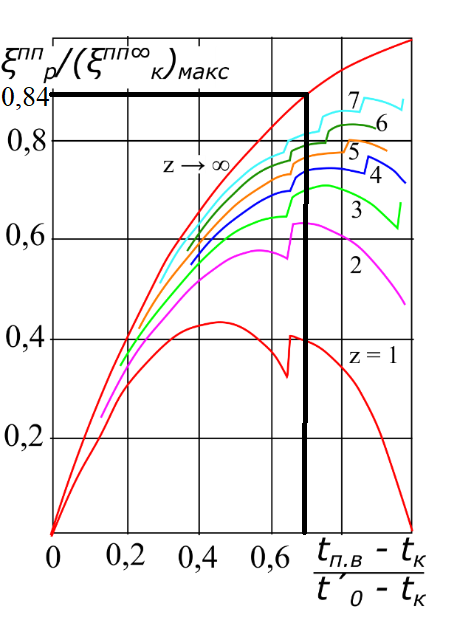

In [24]:
G_golova, G_kond = a.get_mas_flow(a.get_input(0.84))
print("Расход в голову турбины равен = ", G_golova)
print("Расход в конденсатор равен = ", G_kond)

Расход в голову турбины равен =  310.9647960078744
Расход в конденсатор равен =  208.83599937270975


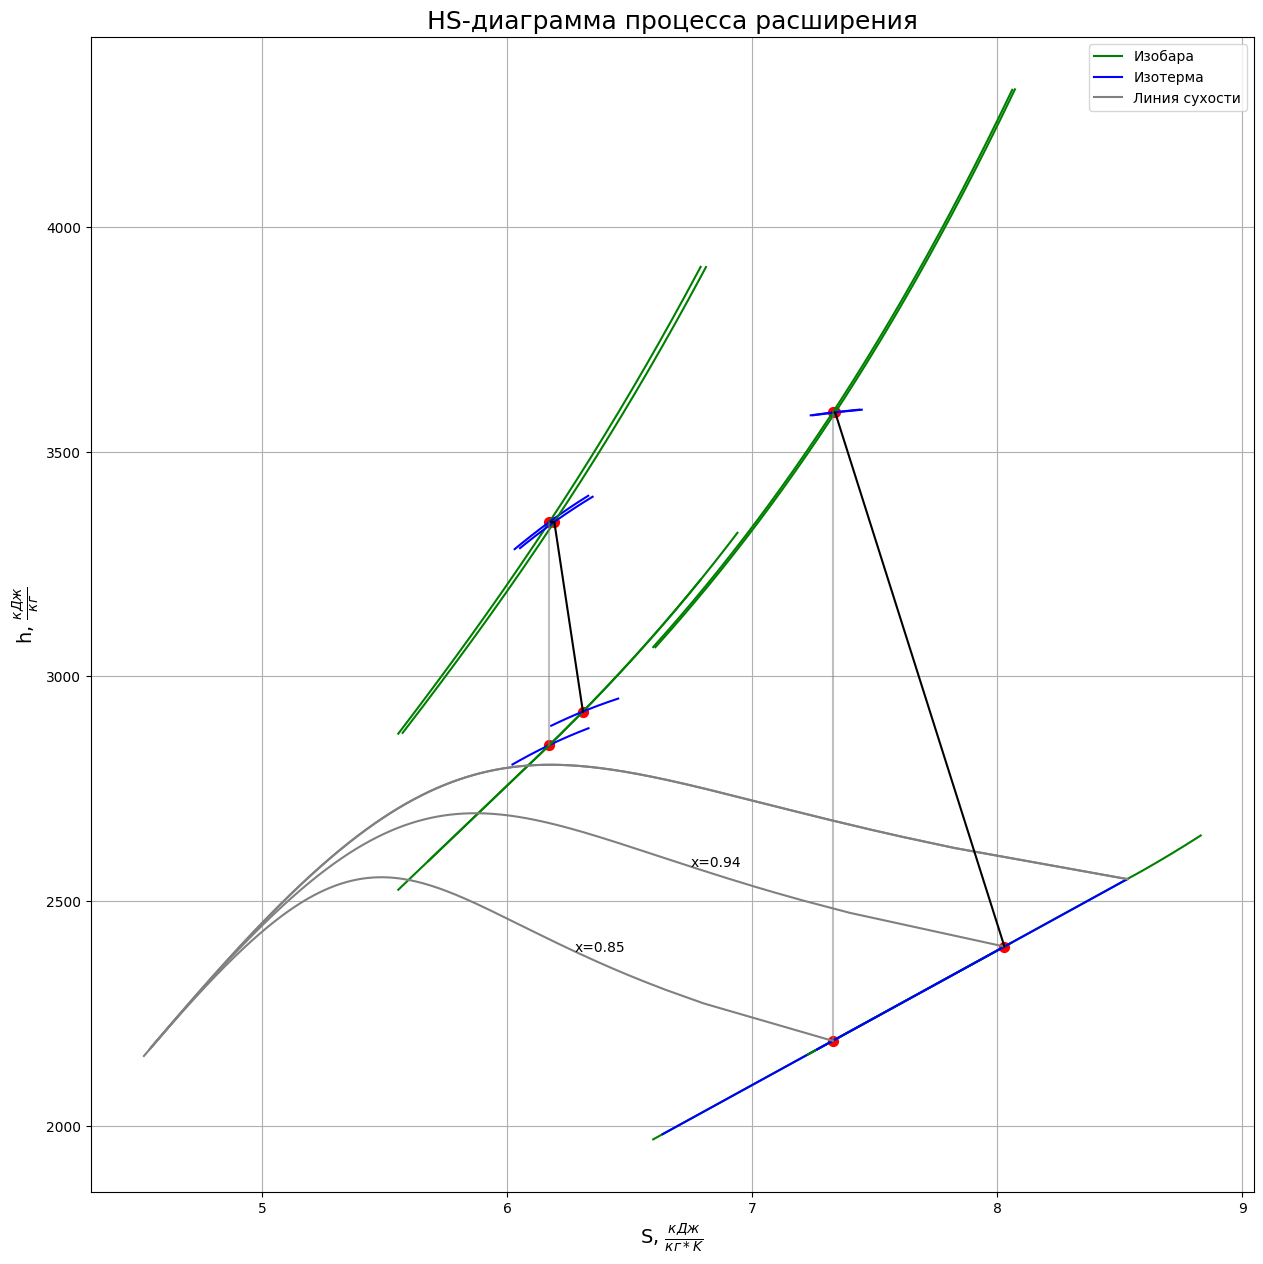

In [25]:
fig, ax = hs.plt.subplots(1, 1, figsize=(15, 15))
hs.plot_hs_diagram(
    ax,
    points=[a._point_0, a.point_0_true, a._point_1, a.point_1_true, a._point_pp, a.point_pp_true, a._point_k,
            a.point_k_true]
)
hs.plot_process(ax, points=[a._point_0, a.point_0_true, a.point_1_true], color='black')
hs.plot_process(ax, points=[a._point_pp, a.point_pp_true, a.point_k_true], color='black')
hs.plot_process(ax, points=[a._point_0, a._point_1], alpha=0.5, color='grey')
hs.plot_process(ax, points=[a._point_pp, a._point_k], alpha=0.5, color='grey')
plt.show()

# Задание №2. Проведение расчета регулирующей ступени и определение зависимости $η_о$$_л$ от $U/$$с_ф$. Диапазон варьируемого теплоперепад. Обоснованно выбрать вариант исполнения регулирующей ступени для проектирования ЦВД в рамках заданного диапазона

In [26]:
from iapws import IAPWS97 as par
import numpy as np
import determination_of_turbine_parameters as tr
import matplotlib.pyplot as plt 
import pandas as pd

# Сопловая решетка 

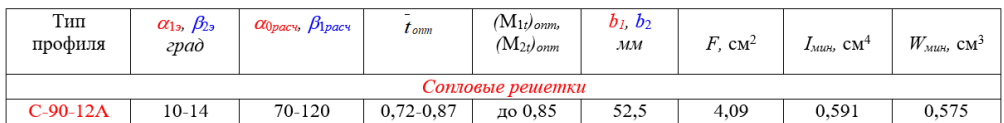

# Рабочая решетка 

# Поиск оптимального диаметра

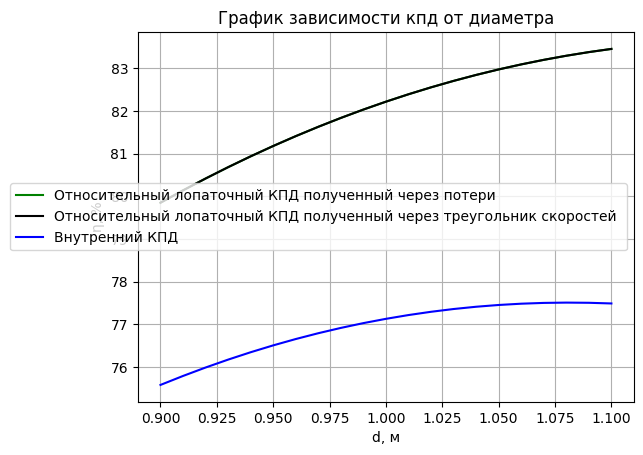

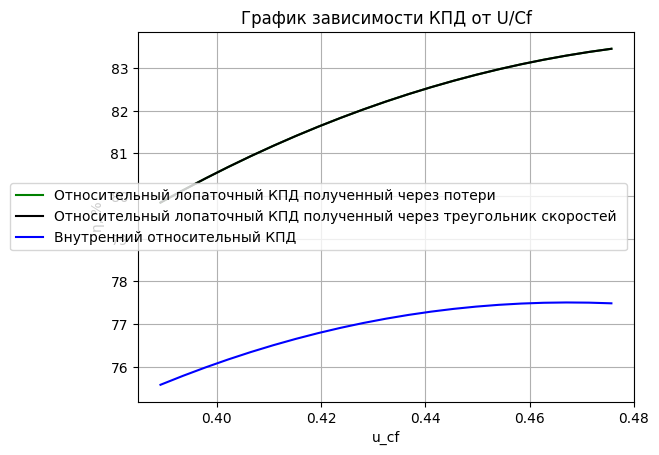

In [27]:
efficiency_loss = []
efficiency_velocity = []
efficiency_internal = []
u_cf = []
for d in np.arange(0.9,1.1,0.01):     #H 
    lop = tr.RegularTurbin(tochka_o = a._point_0, 
                    n = 60,
                       d = d,
                        H_o = 95, 
                         ro = 0.15,
                          G = G_golova, 
                           k = 1.33)
    lop.calc_sopl_lop(b_1 =  52.5 , alpha_1_e = 14 , t_1opt = 0.72)
    lop.calc_for_find_koef_rab_lop(pere = 0.006)
    lop.calc_rab_lop(b_2 = 25.9, t_opt_2 = 0.6) 
    eff_ol_loss, eff_ol_velocity =lop.calc_eff(xi_vs = 0)
    N_i, kpd_oi= lop.calc_int_power(z= 7, i =4)
    efficiency_loss.append(eff_ol_loss * 100)
    efficiency_velocity.append(eff_ol_velocity * 100)
    efficiency_internal.append(kpd_oi * 100)
    u_cf.append(lop.u_c_f)

d = np.arange(0.9,1.1,0.01)
plt.title("График зависимости кпд от диаметра") 
plt.xlabel("d, м") 
plt.ylabel("η, %")     
plt.plot(d,efficiency_loss[:30] , color ="green", label = "Относительный лопаточный КПД полученный через потери ")
plt.plot(d,efficiency_velocity[:30], color ="black",label = "Относительный лопаточный КПД полученный через треугольник скоростей ")
plt.plot(d,efficiency_internal[:30], color ="blue",label = "Внутренний КПД ")
plt.grid()
plt.legend()
plt.show()

plt.title("График зависимости КПД от U/Cf") 
plt.xlabel("u_cf") 
plt.ylabel("η, %")     
plt.plot(u_cf,efficiency_loss, color ="green", label = "Относительный лопаточный КПД полученный через потери ")
plt.plot(u_cf,efficiency_velocity, color ="black",label = "Относительный лопаточный КПД полученный через треугольник скоростей ")
plt.plot(u_cf,efficiency_internal, color ="blue",label = "Внутренний относительный КПД ")
plt.grid()
plt.legend()
plt.show()

In [28]:
lop = tr.RegularTurbin(tochka_o = a._point_0, 
                    n = 60,
                       d = 1.1,
                        H_o = 95, 
                         ro = 0.15,
                          G = G_golova, 
                           k = 1.33)
l = lop.calc_sopl_lop(b_1 =  52.5 , alpha_1_e = 14 , t_1opt = 0.72) 
lop.calc_for_find_koef_rab_lop(pere = 0.006)
lop.calc_rab_lop(b_2 = 25.9, t_opt_2 = 0.6) 
eff_oi_loss, eff_oi_velocity =lop.calc_eff(xi_vs = 0)
N_i,efficiency_internal = lop.calc_int_power(z= 7, i =4)
sigma_bend, sigma_streth, b_2 = lop.calc_stength(W_atl = 0.225 ,b_2_atl = 25.9,sigma_bend_dop = 20 )
table_v_d,table_loss, table_points = lop.tabl()
tochka_1_t, tochka_1, tochka_2_t, tochka_2 = lop.points()

# Значения потерь

In [29]:
table_loss

,"Потери, %"
,
В сопловой решетке,8.254
В рабочей решетке,5.201
Энергия выходной скорости,3.092
Абсолютные потери от утечек через периферийное уплотнение ступени,3.343
Абсолютные потери от трения диска,0.761
Абсолютные потери от парциальности,1.861


# Значения КПД, напряжений и мощности

In [30]:
print(f"Внутренняя мощность ступени N_i: {np.round(N_i,3)} кВт")
print(f"Изгибающие напряжения σ_и: {np.round(sigma_bend,3)} МПа")
print(f"Напряжение растяжения в корневом сечении рабочей лопатки σ_р: {np.round(sigma_streth,3)} МПа")
print(f"Относительный лопаточный КПД полученный через потери : {np.round(eff_oi_loss * 100,3)} %")
print(f"Относительный лопаточный КПД полученный через треугольник скоростей : {np.round(eff_oi_velocity * 100,3)} %")
print(f"Внутренний относительный КПД  : {np.round(efficiency_internal * 100,3)} %")

Внутренняя мощность ступени N_i: 22891.043 кВт
Изгибающие напряжения σ_и: 43.004 МПа
Напряжение растяжения в корневом сечении рабочей лопатки σ_р: 15.822 МПа
Относительный лопаточный КПД полученный через потери : 83.453 %
Относительный лопаточный КПД полученный через треугольник скоростей : 83.453 %
Внутренний относительный КПД  : 77.487 %


# Процесс расширения ступени

,"P, МПа","T, К, °","h, кДж/кг","s,кДж/(кг*К)"
,,,,
Параметры перед ступенью,26.000,828.150,3343.964,6.172
Теоретичекие параметры за сопловой решеткой,20.039,780.087,3263.214,6.172
Параметры за сопловой решеткой,20.039,782.524,3271.055,6.182
Теоретичекие параметры за ступенью,19.113,774.043,3256.805,6.182
Параметры за ступенью,19.113,775.589,3261.746,6.189


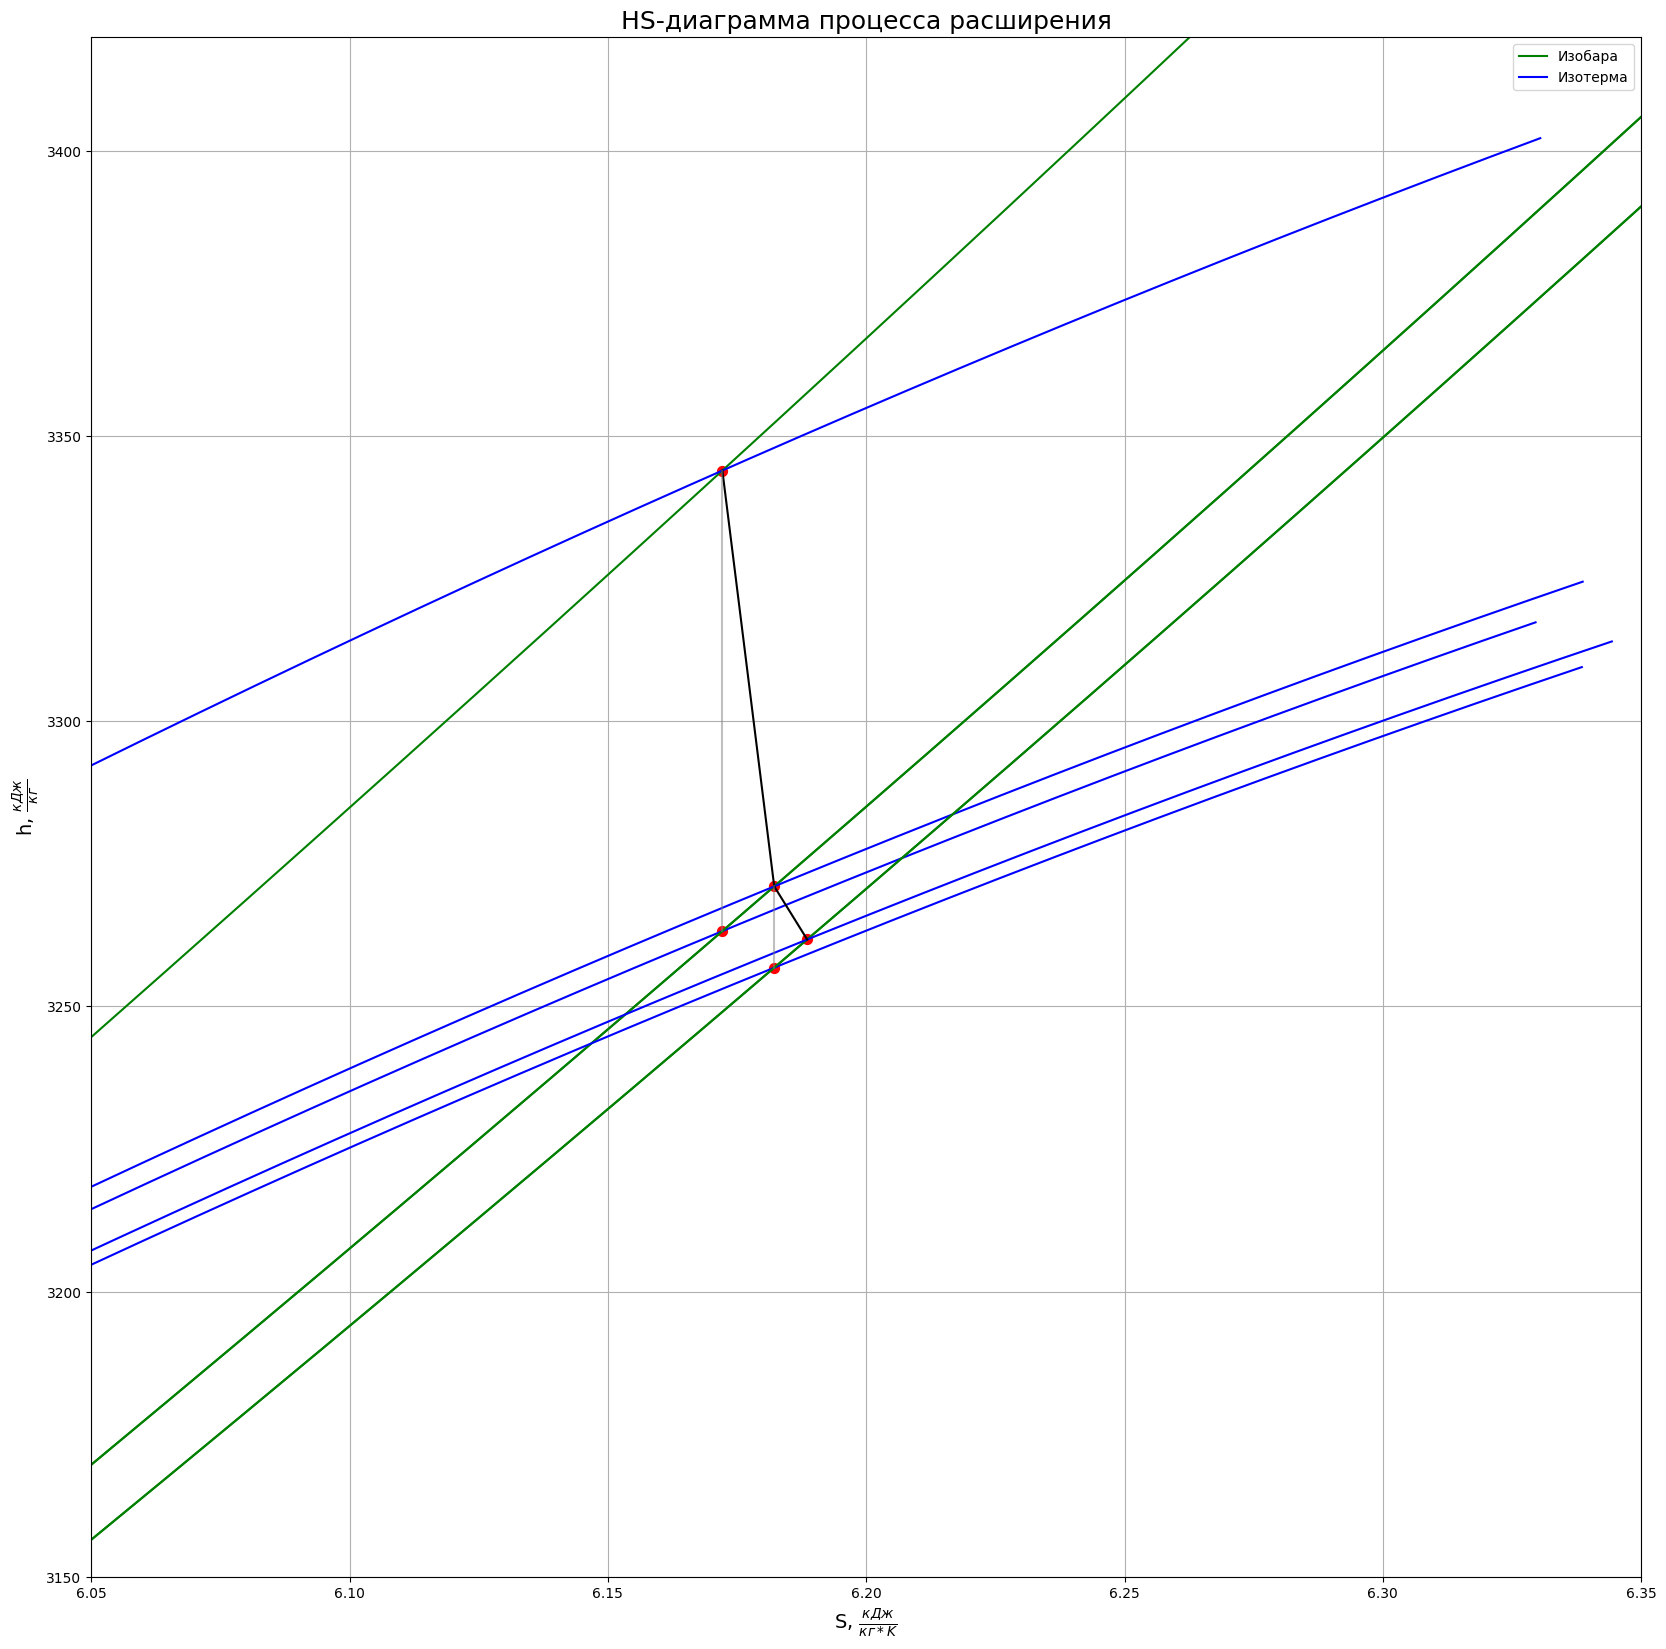

In [31]:
table_points
fig, ax  = hs.plt.subplots(1, 1, figsize=(20, 20))
hs.plot_hs_diagram(
    ax,
    points=[a._point_0,tochka_1_t, tochka_1, tochka_2_t, tochka_2]
)
ax.set_xlim(6.05, 6.35)
ax.set_ylim(3150, 3420)
hs.plot_process(ax, points=[a._point_0, tochka_1], color='black')
hs.plot_process(ax, points=[tochka_1, tochka_2], color='black')
hs.plot_process(ax, points=[a._point_0, tochka_1_t], alpha=0.5, color='grey')
hs.plot_process(ax, points=[tochka_1, tochka_2_t], alpha=0.5, color='grey')
table_points

# Треугольник скоростей

,"Абсолютная скорость (с), м/с","Абсолютный угол (α) , °","Относительная скорость выхода (w) , м/с","Относительный угол (β) , °"
,,,,
За сопловой решеткой,381.86,14.28,188.012,30.065
За рабочей решеткой,76.65,81.00,232.308,19.006


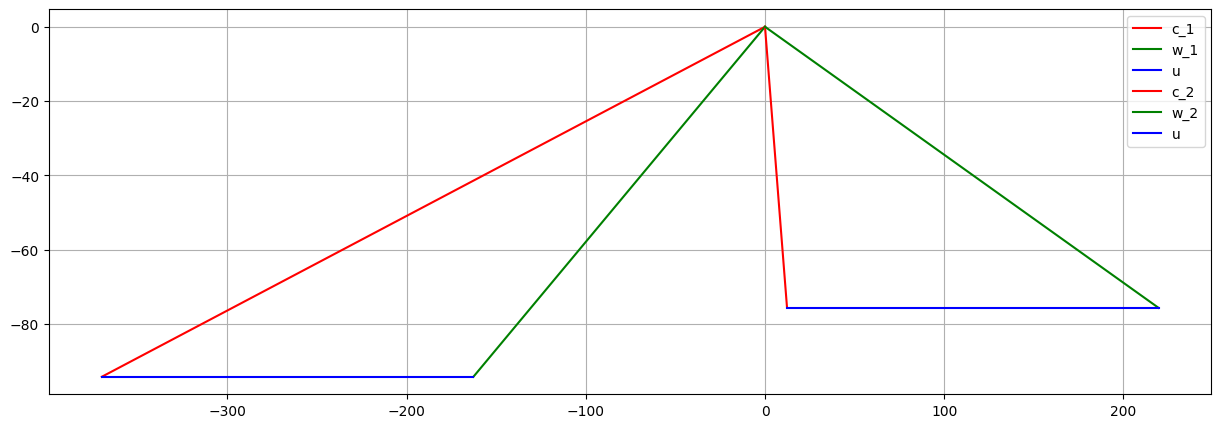

In [32]:
lop.triangle()
table_v_d